In [22]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from glob import glob

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [ ]:
!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip
!unzip -q tiny-imagenet-200.zip

In [18]:
DATA_DIR = 'tiny-imagenet-200/train'

SELECTED_CLASSES = [
    'n01443537',  # goldfish
    'n01641577',  # bullfrog
    'n01698610',  # alligator lizard
    'n01742172',  # black widow
    'n01882714',  # koala
    'n02002724',  # black stork
    'n02056570',  # king penguin
    'n02085620',  # Chihuahua
    'n02099601',  # golden retriever
    'n02123045',  # tabby cat
]

class_to_idx = {cls_name: i for i, cls_name in enumerate(SELECTED_CLASSES)}
print(f"Всего классов: {len(SELECTED_CLASSES)}")
print(class_to_idx)

BATCH_SIZE = 64
IMAGE_SIZE = 128
EPOCHS = 15
LEARNING_RATE = 1e-3

Всего классов: 10
{'n01443537': 0, 'n01641577': 1, 'n01698610': 2, 'n01742172': 3, 'n01882714': 4, 'n02002724': 5, 'n02056570': 6, 'n02085620': 7, 'n02099601': 8, 'n02123045': 9}


## Часть 1. Классификатор 128×128
- Требования к модели:
  - Своя архитектура (разрешается вдохновляться CNN-идеями: Conv-BN-ReLU, блоки с даунсемплингом, GAP и т.д.).
  - Ограничение на параметризованность: не более ~5M параметров.
  - Вход: 128×128×3.
  - Можно выбрать любое количество классов для обучения!
- Обучение:
  - Трен/вал сплит: выберите собственную стратификацию.
  - Аугментации: разумные (кроп, флипы, color jitter и т.д.), кратко опишите в отчёте.
- Что сдаём по части 1:
  - График/лог обучения (loss/accuracy по эпохам) и итоговые метрики на валидации.
  - Чекпоинт модели (по возможности) или веса/ссылка.

In [20]:
class TinySubsetDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

all_image_paths = []
all_labels = []

for cls_name in SELECTED_CLASSES:
    cls_folder = os.path.join(DATA_DIR, cls_name, 'images')
    if os.path.isdir(cls_folder):
        images = glob(os.path.join(cls_folder, '*.JPEG'))
        for img_path in images:
            all_image_paths.append(img_path)
            all_labels.append(class_to_idx[cls_name])

print(f"Всего изображений найдено: {len(all_image_paths)}")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_image_paths, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)), # Апскейл 64 -> 128
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = TinySubsetDataset(train_paths, train_labels, transform=train_transforms)
val_dataset = TinySubsetDataset(val_paths, val_labels, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")

Всего изображений найдено: 4500
Train size: 3600, Val size: 900


In [28]:
class ResNetMicro(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNetMicro, self).__init__()
        self.in_channels = 32

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)

        # Каналы: 32 -> 64 -> 128 -> 256
        self.layer1 = self._make_layer(32,  2, stride=1)
        self.layer2 = self._make_layer(64,  2, stride=2)
        self.layer3 = self._make_layer(128, 2, stride=2)
        self.layer4 = self._make_layer(256, 2, stride=2)

        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

model = ResNetMicro(num_classes=len(SELECTED_CLASSES)).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

params = count_parameters(model)
print(f"Количество параметров модели: {params:,}")

Количество параметров модели: 2,797,610


In [31]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'lr': []
}

In [32]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total

def val_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Validating", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total

print("Starting training with ResNet-Lite...")

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = val_epoch(model, val_loader, criterion)

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    print(f"Epoch [{epoch+1}/{EPOCHS}] LR: {current_lr:.1e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print("Training finished.")

Starting training with ResNet-Lite...


Training:   0%|          | 0/57 [00:00<?, ?it/s]

Validating:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [1/15] LR: 1.0e-03 | Train Loss: 1.9698 Acc: 0.2800 | Val Loss: 1.9898 Acc: 0.3211


Training:   0%|          | 0/57 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [14/15] LR: 1.0e-03 | Train Loss: 1.1643 Acc: 0.5881 | Val Loss: 1.9526 Acc: 0.4356


Training:   0%|          | 0/57 [00:00<?, ?it/s]

Validating:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [15/15] LR: 1.0e-03 | Train Loss: 1.1225 Acc: 0.6069 | Val Loss: 1.2687 Acc: 0.5511
Training finished.


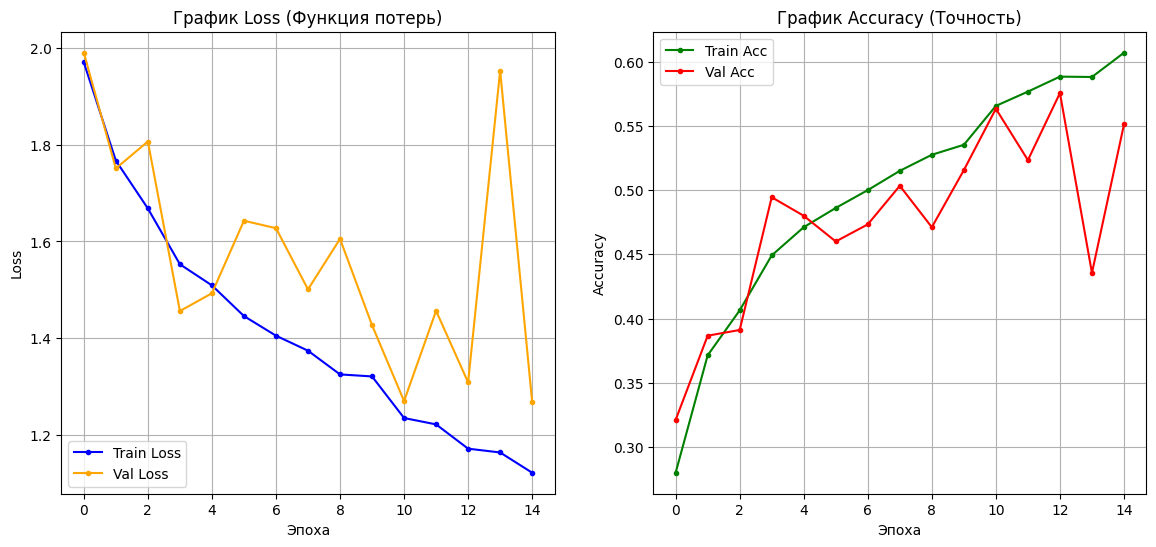

In [34]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', marker='.')
plt.plot(history['val_loss'], label='Val Loss', color='orange', marker='.')
plt.title('График Loss (Функция потерь)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc', color='green', marker='.')
plt.plot(history['val_acc'], label='Val Acc', color='red', marker='.')
plt.title('График Accuracy (Точность)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

In [33]:
checkpoint_name = 'tiny_imagenet_resnet_micro_128px.pth'
torch.save(model.state_dict(), checkpoint_name)

print(f"\nЧекпоинт модели сохранен как '{checkpoint_name}'")
print(f"Размер файла: {os.path.getsize(checkpoint_name) / 1024 / 1024:.2f} MB")


Чекпоинт модели сохранен как 'tiny_imagenet_resnet_micro_128px.pth'
Размер файла: 10.73 MB


## Часть 2. Базовая U-Net на "Луне"
- Требования к архитектуре U-Net (зафиксируйте и опишите в отчёте):
  - Глубина: 4 уровня down/4 up (энкодер-декодер с skip-связями).
  - Базовые каналы на первом уровне: 32 или 64 (по желанию можно выбрать свое количество каналов, но надо будет объяснить).
  - Даунсемплинг: stride 2 или MaxPool.
  - Итоговый слой: 1 канал с сигмоидой (бинарная сегментация).
  - Ограничение на количество параметров: до ~2.5M (рекомендуется укладываться, но допускается ±10%).
  - Вход: 128×128×3.
- Обучение:
  - Лосс: BCEWithLogitsLoss или Dice Loss, допустимо комбинировать (например, 0.5*BCE + 0.5*Dice).
  - Метрики для мониторинга: IoU (Jaccard), Dice, Pixel Accuracy.
  - Аугментации: горизонтальные/вертикальные флипы, лёгкие геометрические и цветовые — по желанию (можно добавлять другие).
- Что сдаём по части 2:
  - Логи обучения и итоговые метрики на валидации: IoU, Dice, Pixel Acc.
  - 3–5 визуализаций: вход, предсказанная маска, GT маска.

In [40]:
import gc

try:
    del model
    del optimizer
    del criterion
    del train_loader
    del val_loader
    del scheduler
    print("Переменные Части 1 удалены.")
except NameError:
    print("Переменные уже были удалены или не существовали.")

torch.cuda.empty_cache()
gc.collect()

print("GPU память очищена.")

Переменные уже были удалены или не существовали.
GPU память очищена.


In [42]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as TF

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 128
BATCH_SIZE = 16
LR = 1e-3
EPOCHS = 20

DATA_ROOT = 'moon_data/MOON_SEGMENTATION_BINARY'

print(f"Device: {DEVICE}")

Device: cuda


In [43]:
class MoonDataset(Dataset):
    def __init__(self, root_dir, augment=False):
        self.root_dir = root_dir
        self.augment = augment

        # Сбор путей
        self.img_dir = os.path.join(root_dir, 'images', 'render')
        self.mask_dir = os.path.join(root_dir, 'images', 'ground')

        self.images = sorted(glob.glob(os.path.join(self.img_dir, '*.png')))
        self.masks = sorted(glob.glob(os.path.join(self.mask_dir, '*.png')))

        # Проверка целостности
        if len(self.images) == 0:
            raise RuntimeError(f"Изображения не найдены в {self.img_dir}")
        assert len(self.images) == len(self.masks), "Разное количество картинок и масок!"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Загрузка
        img_path = self.images[idx]
        mask_path = self.masks[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = TF.resize(image, (IMG_SIZE, IMG_SIZE))
        mask = TF.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=Image.NEAREST)

        if self.augment:
            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

        image = TF.to_tensor(image) # [3, 128, 128], 0..1
        mask = TF.to_tensor(mask)   # [1, 128, 128], 0..1

        return image, mask

full_dataset = MoonDataset(DATA_ROOT, augment=True)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_subset, val_subset = random_split(full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Всего изображений: {len(full_dataset)}")
print(f"Train: {len(train_subset)}, Val: {len(val_subset)}")

Всего изображений: 1000
Train: 800, Val: 200


In [46]:
class DoubleConv(nn.Module):
    """(Conv -> BN -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class UNetLite(nn.Module):
    def __init__(self, n_channels=3, n_classes=1):
        super(UNetLite, self).__init__()

        base = 16

        # --- Encoder (Downsampling) ---
        self.inc = DoubleConv(n_channels, base)           # 3 -> 16

        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base, base*2))      # 16 -> 32
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*2, base*4))    # 32 -> 64
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*4, base*8))    # 64 -> 128
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*8, base*16))   # 128 -> 256 (Bottleneck)

        # Up 1
        self.up1 = nn.ConvTranspose2d(base*16, base*8, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(base*16, base*8)

        # Up 2
        self.up2 = nn.ConvTranspose2d(base*8, base*4, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(base*8, base*4)

        # Up 3
        self.up3 = nn.ConvTranspose2d(base*4, base*2, kernel_size=2, stride=2)
        self.conv_up3 = DoubleConv(base*4, base*2)

        # Up 4
        self.up4 = nn.ConvTranspose2d(base*2, base, kernel_size=2, stride=2)
        self.conv_up4 = DoubleConv(base*2, base)

        # Final output
        self.outc = nn.Conv2d(base, n_classes, kernel_size=1)

    def forward(self, x):
        # Down
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4) # Bottleneck

        # Up 1
        x = self.up1(x5)

        # Skip connection x4
        x = torch.cat([x4, x], dim=1)
        x = self.conv_up1(x)

        # Up 2
        x = self.up2(x)
        x = torch.cat([x3, x], dim=1)
        x = self.conv_up2(x)

        # Up 3
        x = self.up3(x)
        x = torch.cat([x2, x], dim=1)
        x = self.conv_up3(x)

        # Up 4
        x = self.up4(x)
        x = torch.cat([x1, x], dim=1)
        x = self.conv_up4(x)

        logits = self.outc(x)
        return logits

model = UNetLite().to(DEVICE)

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Количество параметров U-Net: {params:,}")

Количество параметров U-Net: 1,942,577


In [47]:
def compute_metrics(pred_logits, true_masks, threshold=0.5):
    # Logits -> Probabilities
    probs = torch.sigmoid(pred_logits)
    preds = (probs > threshold).float()

    preds_flat = preds.view(-1)
    masks_flat = true_masks.view(-1)

    correct = (preds_flat == masks_flat).sum().item()
    total = masks_flat.numel()
    pixel_acc = correct / total

    intersection = (preds_flat * masks_flat).sum().item()
    union = preds_flat.sum().item() + masks_flat.sum().item()
    dice = (2. * intersection) / (union + 1e-8)

    iou = intersection / (union - intersection + 1e-8)

    return pixel_acc, dice, iou

class DiceBCELoss(nn.Module):
    def __init__(self, weight=0.5):
        super(DiceBCELoss, self).__init__()
        self.weight = weight

    def forward(self, inputs, targets, smooth=1):
        bce_loss = F.binary_cross_entropy_with_logits(inputs, targets)

        inputs_prob = torch.sigmoid(inputs)
        inputs_flat = inputs_prob.view(-1)
        targets_flat = targets.view(-1)

        intersection = (inputs_flat * targets_flat).sum()
        dice_loss = 1 - (2.*intersection + smooth)/(inputs_flat.sum() + targets_flat.sum() + smooth)

        return (1 - self.weight) * bce_loss + self.weight * dice_loss

criterion = DiceBCELoss(weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [48]:
from tqdm.notebook import tqdm

history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}

print("Начинаем обучение U-Net...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    # Training Loop
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # Validation Loop
    model.eval()
    val_loss = 0
    val_iou = 0
    val_dice = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

            # Метрики
            _, dice, iou = compute_metrics(outputs, masks)
            val_iou += iou
            val_dice += dice

    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_iou'].append(avg_val_iou)
    history['val_dice'].append(avg_val_dice)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
          f"Dice: {avg_val_dice:.4f} | IoU: {avg_val_iou:.4f}")

Начинаем обучение U-Net...


Epoch 1/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [1/20] Train Loss: 0.5883 | Val Loss: 0.5818 | Dice: 0.1340 | IoU: 0.0722


Epoch 2/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [2/20] Train Loss: 0.5035 | Val Loss: 0.4874 | Dice: 0.5046 | IoU: 0.3385


...

Epoch [18/20] Train Loss: 0.3001 | Val Loss: 0.3528 | Dice: 0.5840 | IoU: 0.4140


Epoch 19/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [19/20] Train Loss: 0.2989 | Val Loss: 0.3144 | Dice: 0.6387 | IoU: 0.4711


Epoch 20/20:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch [20/20] Train Loss: 0.2966 | Val Loss: 0.3318 | Dice: 0.6034 | IoU: 0.4337


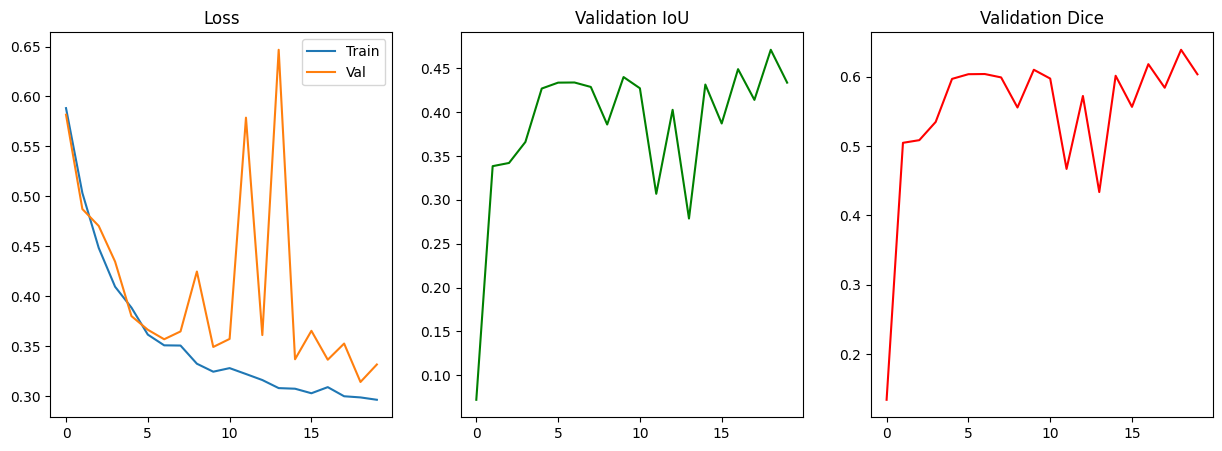

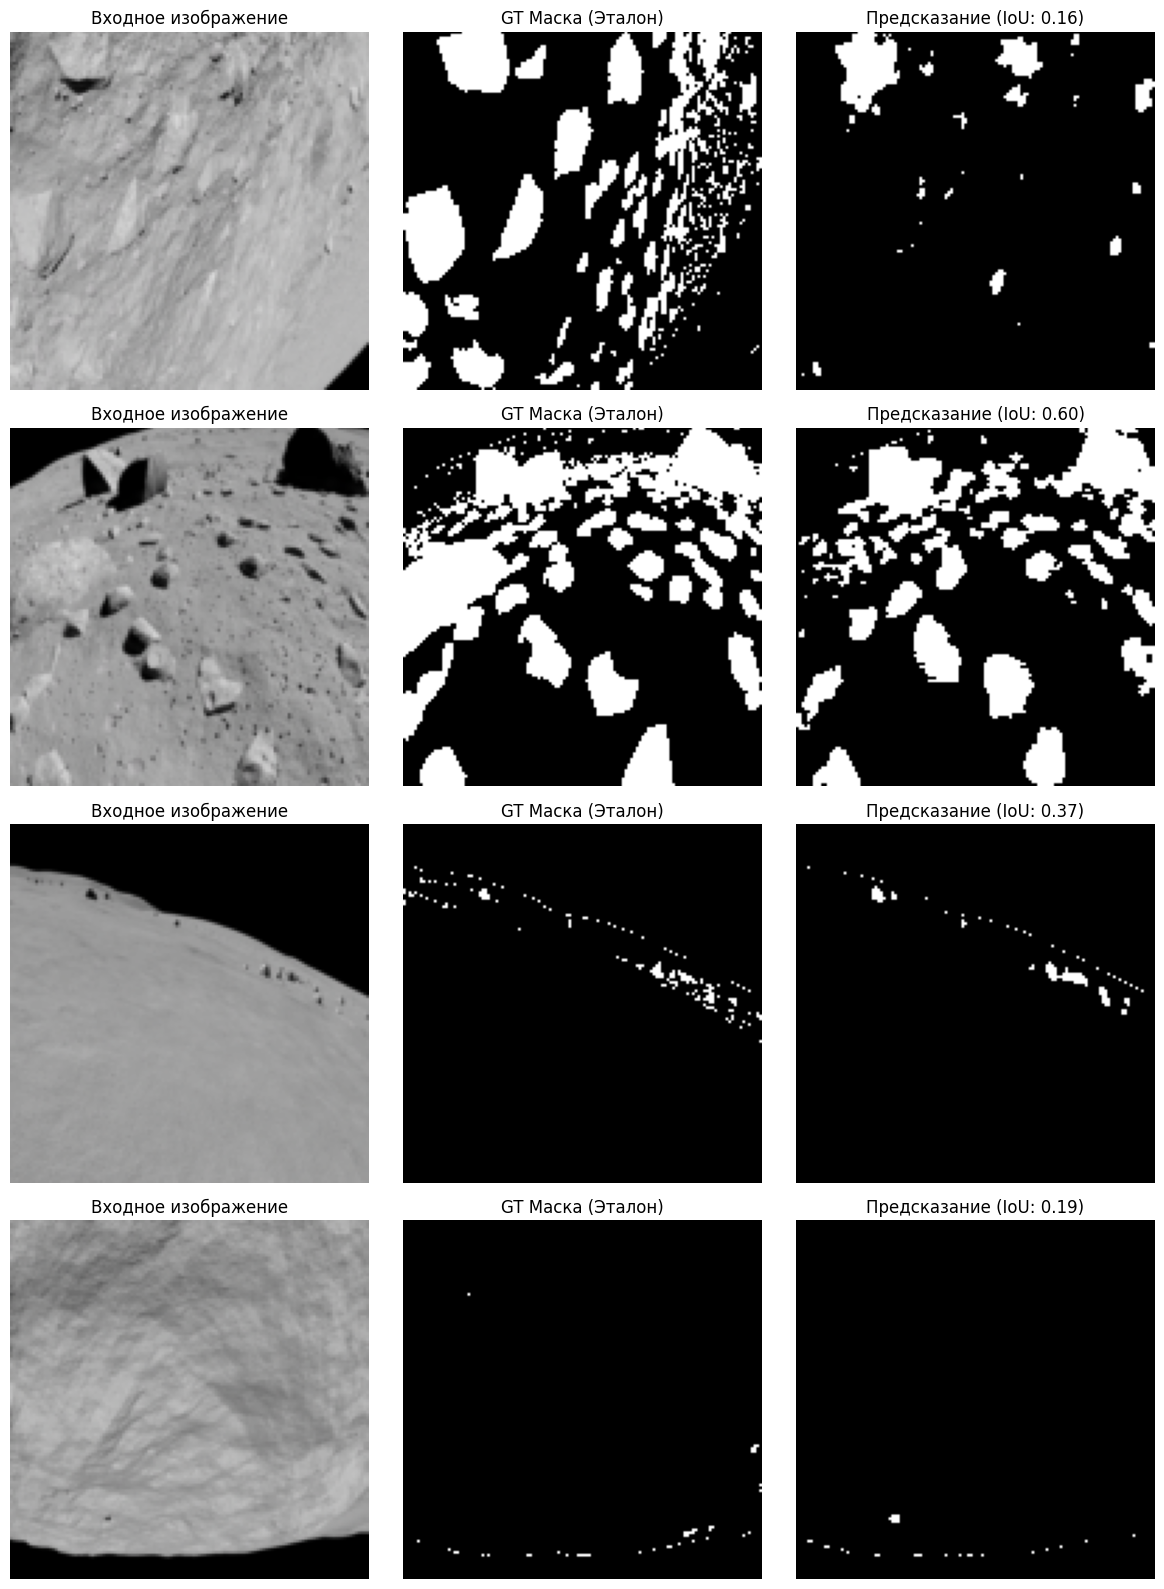

Final Validation IoU: 0.4337
Final Validation Dice: 0.6034


In [49]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['val_iou'], label='IoU', color='green')
plt.title('Validation IoU')

plt.subplot(1, 3, 3)
plt.plot(history['val_dice'], label='Dice', color='red')
plt.title('Validation Dice')
plt.show()

model.eval()
images, masks = next(iter(val_loader))
images = images.to(DEVICE)

with torch.no_grad():
    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

n_samples = 4
plt.figure(figsize=(12, 4*n_samples))

for i in range(n_samples):
    img_show = images[i].cpu().permute(1, 2, 0).numpy()
    mask_show = masks[i].cpu().squeeze().numpy()
    pred_show = preds[i].cpu().squeeze().numpy()

    _, dice, iou = compute_metrics(logits[i:i+1], masks[i:i+1].to(DEVICE))

    plt.subplot(n_samples, 3, i*3 + 1)
    plt.imshow(img_show)
    plt.title("Входное изображение")
    plt.axis('off')

    plt.subplot(n_samples, 3, i*3 + 2)
    plt.imshow(mask_show, cmap='gray')
    plt.title("GT Маска (Эталон)")
    plt.axis('off')

    plt.subplot(n_samples, 3, i*3 + 3)
    plt.imshow(pred_show, cmap='gray')
    plt.title(f"Предсказание (IoU: {iou:.2f})")
    plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Final Validation IoU: {history['val_iou'][-1]:.4f}")
print(f"Final Validation Dice: {history['val_dice'][-1]:.4f}")

## Часть 3. U-Net с бэкбоном из классификатора
- Идея: использовать энкодер из вашей модели классификации как бэкбон U‑Net.
  - Вариант A (заморозка): заморозить веса энкодера, обучать только декодер.
  - Вариант B (тонкая настройка): полностью разморозить энкодер на поздних этапах.
  - Если у классификатора есть GAP/FC-голова — удалите её; возьмите сверточные блоки до глобального усреднения как энкодерные стадии.
- Ограничения и замечания:
  - Если количество стадий не совпадает, добавьте адаптационные 1×1 свёртки и интерполяции/пулинг, но опишите это.
- Обучение:
  - Тот же датасет "луна", те же метрики.
  - Сравните результаты с базовой U‑Net из части 2 (таблица метрик).
- Что сдаём по части 3:
  - Метрики и сравнение с базовой U‑Net (желательно таблица).

In [50]:
import gc
import torch

if 'model' in globals():
    del model
if 'optimizer' in globals():
    del optimizer

torch.cuda.empty_cache()
gc.collect()

35404

In [51]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNetMicroEncoder(nn.Module):
    def __init__(self):
        super(ResNetMicroEncoder, self).__init__()
        self.in_channels = 32

        # Stem
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)

        # Layers
        self.layer1 = self._make_layer(32,  2, stride=1) # 128x128
        self.layer2 = self._make_layer(64,  2, stride=2) # 64x64
        self.layer3 = self._make_layer(128, 2, stride=2) # 32x32
        self.layer4 = self._make_layer(256, 2, stride=2) # 16x16 (Bottleneck)


    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        features = []

        x = F.relu(self.bn1(self.conv1(x))) # Stem result: 32ch, 128x128

        x1 = self.layer1(x)  # -> 32ch, 128x128
        features.append(x1)

        x2 = self.layer2(x1) # -> 64ch, 64x64
        features.append(x2)

        x3 = self.layer3(x2) # -> 128ch, 32x32
        features.append(x3)

        x4 = self.layer4(x3) # -> 256ch, 16x16
        features.append(x4)

        return features

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)

        conv_in_ch = (in_channels // 2) + skip_channels

        self.conv = nn.Sequential(
            nn.Conv2d(conv_in_ch, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x, skip):
        x = self.up(x)

        if x.size() != skip.size():
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=True)

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class ResNetUNet(nn.Module):
    def __init__(self, encoder_path=None, n_classes=1):
        super(ResNetUNet, self).__init__()

        self.encoder = ResNetMicroEncoder()

        if encoder_path:
            state_dict = torch.load(encoder_path, map_location='cpu')
            missing, unexpected = self.encoder.load_state_dict(state_dict, strict=False)
            print(f"Веса энкодера загружены.")

        # Encoder features shapes:
        # f[0]: 32ch, 128x128
        # f[1]: 64ch, 64x64
        # f[2]: 128ch, 32x32
        # f[3]: 256ch, 16x16 (Bottleneck input)

        # Up 1: Input 256 (from f3) -> Up -> 128. Concat with f2 (128). Out -> 128.
        self.up1 = DecoderBlock(in_channels=256, skip_channels=128, out_channels=128)

        # Up 2: Input 128 -> Up -> 64. Concat with f1 (64). Out -> 64.
        self.up2 = DecoderBlock(in_channels=128, skip_channels=64, out_channels=64)

        # Up 3: Input 64 -> Up -> 32. Concat with f0 (32). Out -> 32.
        self.up3 = DecoderBlock(in_channels=64, skip_channels=32, out_channels=32)

        # Final conv
        self.final_conv = nn.Conv2d(32, n_classes, kernel_size=1)

    def forward(self, x):
        # Encoder
        features = self.encoder(x) # [x1, x2, x3, x4]
        f0, f1, f2, f3 = features[0], features[1], features[2], features[3]

        # Decoder
        x = self.up1(f3, f2)
        x = self.up2(x, f1)
        x = self.up3(x, f0)

        logits = self.final_conv(x)
        return logits

In [53]:
CHECKPOINT_PATH = 'tiny_imagenet_resnet_micro_128px.pth'

model = ResNetUNet(encoder_path=CHECKPOINT_PATH, n_classes=1).to(DEVICE)

for param in model.encoder.parameters():
    param.requires_grad = False

print("Веса энкодера (ResNet) заморожены.")

params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Всего параметров: {params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
criterion = DiceBCELoss(weight=0.5)

Веса энкодера загружены.
Веса энкодера (ResNet) заморожены.
Всего параметров: 3,548,833
Обучаемых параметров: 753,793


In [54]:
from tqdm.notebook import tqdm

history_resunet = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}
EPOCHS_PART3 = 15

print("Запуск обучения ResNet-U-Net...")

for epoch in range(EPOCHS_PART3):
    model.train()
    train_loss = 0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        images, masks = images.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    val_iou = 0
    val_dice = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
            _, dice, iou = compute_metrics(outputs, masks)
            val_iou += iou
            val_dice += dice

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)

    history_resunet['train_loss'].append(avg_train_loss)
    history_resunet['val_loss'].append(avg_val_loss)
    history_resunet['val_iou'].append(avg_val_iou)
    history_resunet['val_dice'].append(avg_val_dice)

    print(f"Epoch {epoch+1} | IoU: {avg_val_iou:.4f} | Dice: {avg_val_dice:.4f}")

Запуск обучения ResNet-U-Net...


Epoch 1:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1 | IoU: 0.3460 | Dice: 0.5129


Epoch 2:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 2 | IoU: 0.3816 | Dice: 0.5511


...

Epoch 13 | IoU: 0.4362 | Dice: 0.6059


Epoch 14:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 14 | IoU: 0.4140 | Dice: 0.5845


Epoch 15:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 15 | IoU: 0.4234 | Dice: 0.5937


Metric          | Base U-Net (Part 2)  | ResNet Backbone (Part 3)
Best IoU        | 0.4711               | 0.4362
Best Dice       | 0.6387               | 0.6059


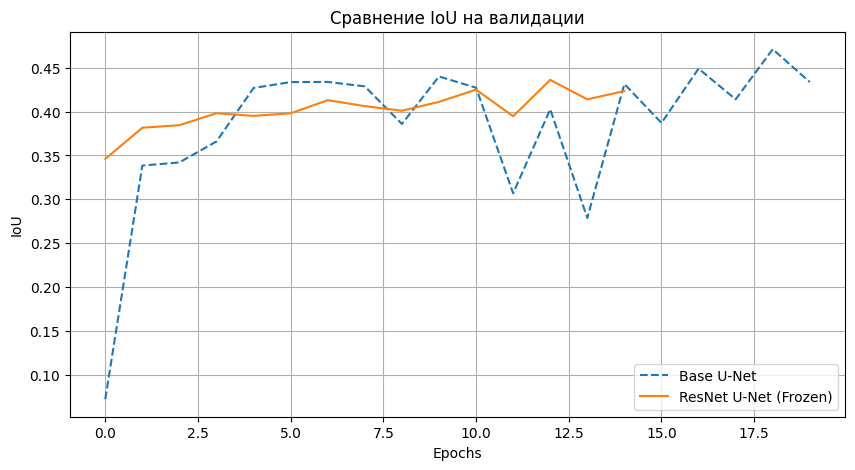

In [55]:
print(f"{'Metric':<15} | {'Base U-Net (Part 2)':<20} | {'ResNet Backbone (Part 3)':<20}")

best_iou_base = max(history['val_iou']) if 'history' in globals() else 0.0
best_dice_base = max(history['val_dice']) if 'history' in globals() else 0.0

best_iou_res = max(history_resunet['val_iou'])
best_dice_res = max(history_resunet['val_dice'])

print(f"{'Best IoU':<15} | {best_iou_base:.4f}{' '*14} | {best_iou_res:.4f}")
print(f"{'Best Dice':<15} | {best_dice_base:.4f}{' '*14} | {best_dice_res:.4f}")

plt.figure(figsize=(10, 5))
if 'history' in globals():
    plt.plot(history['val_iou'], label='Base U-Net', linestyle='--')
plt.plot(history_resunet['val_iou'], label='ResNet U-Net (Frozen)')
plt.title('Сравнение IoU на валидации')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.grid(True)
plt.show()